# Разведочный анализ данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scripts

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)
plt.rcParams.update({
    'figure.figsize': (9, 3.6), 'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
# Цвета одни на весь ноутбук: классы и части данных
HUMAN, BOT = '#4c72b0', '#dd8452'
PART_COLORS = {'research': '#4c72b0', 'holdout': '#8c8c8c', 'test': '#55a868'}

## Данные

Одна строка train или test это одна cookie с суточным окном наблюдения. Target 1 означает трафик известных сервисов сбора данных, а не любую автоматизацию, 0 трафик, отнесённый к человеческому. Предсказание делается в момент `window_end_ts`, всё, что известно позже, в признаки не попадает

Для анализа использовал 04-06..04-16. Метки 04-17..04-19 в этом ноутбуке скрыты через `read_meta` и в расчётах не участвуют. Дневные числа ботов этих дней были просмотрены раньше, поэтому полностью слепым этот блок не был

In [2]:
meta = scripts.read_meta()
events = scripts.read_events()
print('cookie:', meta.shape, '| событий:', events.shape)
# У отложенного блока метки скрыты read_meta, у test их нет: число ботов там не определено
parts = meta.groupby('part', sort=False).agg(
    first_day=('window_start_ts', 'min'), last_day=('window_start_ts', 'max'),
    days=('window_start_ts', 'nunique'), cookies=('cookie_id', 'size'),
    bots=('target', lambda labels: labels.sum(min_count=1)),
)
parts['bot_share'] = (parts['bots'] / parts['cookies']).round(4)
parts['labels'] = parts.index.map({'research': 'есть', 'holdout': 'скрыты', 'test': 'нет'})
parts

cookie: (16000, 6) | событий: (328905, 15)


,first_day,last_day,days,cookies,bots,bot_share,labels
part,,,,,,,
research,2026-04-06,2026-04-16,11,9140,739.0,0.0809,есть
holdout,2026-04-17,2026-04-19,3,1951,NaN,NaN,скрыты
test,2026-04-20,2026-04-26,7,4909,NaN,NaN,нет


Исследовательская часть это 11 дней с 04-06 по 04-16: 9140 cookie, 739 ботов, доля 0.0809. У отложенного блока метки скрыты, у test их нет, поэтому число ботов там не определено. Test занимает полную неделю с понедельника 04-20 по воскресенье 04-26. Все связи с target ниже считаются только по исследовательской части

## Ключи и окна

In [3]:
train_ids = meta.loc[meta['part'] != 'test', 'cookie_id']
test_ids = meta.loc[meta['part'] == 'test', 'cookie_id']
window = meta['window_end_ts'] - meta['window_start_ts']
checks = pd.Series({
    'cookie_id повторяется': meta['cookie_id'].duplicated().sum(),
    'cookie_id есть и в train, и в test': train_ids.isin(test_ids).sum(),
    'событие без cookie в train или test': (~events['cookie_id'].isin(meta['cookie_id'])).sum(),
    'cookie без единого события в файле': (~meta['cookie_id'].isin(events['cookie_id'])).sum(),
    'окно не равно суткам': (window != pd.Timedelta(days=1)).sum(),
    'окно начинается не в полночь': (
        meta['window_start_ts'] != meta['window_start_ts'].dt.normalize()).sum(),
    'cookie создана не раньше начала окна': (
        meta['cookie_created_at'] >= meta['window_start_ts']).sum(),
    'пропуск во времени события': events['event_ts'].isna().sum(),
    'eid с несколькими event_name': (events.groupby('eid')['event_name'].nunique() > 1).sum(),
}, name='нарушений')
assert (checks == 0).all()
print(events.dtypes.to_dict())
checks

{'cookie_id': <StringDtype(na_value=nan)>, 'event_ts': dtype('<M8[us]'), 'eid': dtype('int64'), 'event_name': <StringDtype(na_value=nan)>, 'platform': <StringDtype(na_value=nan)>, 'user_agent': <StringDtype(na_value=nan)>, 'item_id': dtype('float64'), 'item_category': <StringDtype(na_value=nan)>, 'item_location': <StringDtype(na_value=nan)>, 'seller_type': <StringDtype(na_value=nan)>, 'search_query': <StringDtype(na_value=nan)>, 'search_page': dtype('float64'), 'pointer_x': dtype('float64'), 'pointer_y': dtype('float64'), 'row_in_file': dtype('int64')}


cookie_id повторяется                   0
cookie_id есть и в train, и в test      0
событие без cookie в train или test     0
cookie без единого события в файле      0
окно не равно суткам                    0
окно начинается не в полночь            0
cookie создана не раньше начала окна    0
пропуск во времени события              0
eid с несколькими event_name            0
Name: нарушений, dtype: int64

Каждая cookie встречается ровно в одном окне, поэтому одна cookie не может попасть и в обучение, и в проверку. Окна ровно сутки от полуночи, `eid` однозначно задаёт `event_name`, время события разобрано без пропусков

In [4]:
# Возраст cookie на начало окна: сколько часов прошло с первого появления cookie
age_hours = (meta['window_start_ts'] - meta['cookie_created_at']).dt.total_seconds() / 3600
age_hours.groupby(meta['part']).describe().round(1)

,count,mean,std,min,25%,50%,75%,max
part,,,,,,,,
holdout,1951.0,1657.0,1575.9,0.9,189.0,1333.4,2543.5,10782.8
research,9140.0,1739.3,1614.3,0.3,336.0,1445.9,2618.2,10538.2
test,4909.0,1719.5,1632.0,0.5,291.3,1407.1,2583.4,11167.0


Все cookie созданы до начала окна, минимальный возраст 0.3 часа, медиана около 1400 часов, то есть примерно два месяца. Возраст берётся из метаданных cookie, а не из событий: событий раньше начала окна в файле нет

## Границы окна

Окно включает начало и исключает конец: `window_start_ts <= event_ts < window_end_ts`. Ниже распределение событий до фильтрации, train включает все размеченные дни

In [5]:
located = scripts.attach_window(events, meta)
located['side'] = np.where(located['part'] == 'test', 'test', 'train')
late = located[located['position'].isin(['at_end', 'after'])]
late_hours = (late['event_ts'] - late['window_end_ts']).dt.total_seconds() / 3600
print('событий с event_ts >= window_end_ts:', len(late),
      '| строго позже:', (late_hours > 0).sum(), '| ровно на границе:', (late_hours == 0).sum())
print('cookie с такими событиями:', late['cookie_id'].nunique(),
      '| самое позднее событие, часов после конца окна:', round(late_hours.max(), 1))
pd.crosstab(located['side'], located['position'])

событий с event_ts >= window_end_ts: 40779 | строго позже: 40711 | ровно на границе: 68
cookie с такими событиями: 5280 | самое позднее событие, часов после конца окна: 15.7


position,after,at_end,inside
side,,,
test,0,0,89690
train,40711,68,198436


В train 40779 событий с `event_ts >= window_end_ts`: 40711 позже конца окна и 68 ровно на границе. Они принадлежат 5280 cookie, самое позднее на 15.7 часа позже конца окна. В test таких событий нет, раньше начала окна событий нет нигде

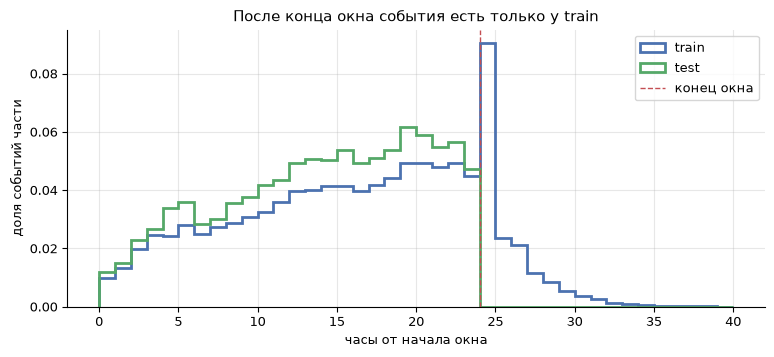

In [6]:
hours = (located['event_ts'] - located['window_start_ts']).dt.total_seconds() / 3600
fig, ax = plt.subplots()
for side, color in [('train', PART_COLORS['research']), ('test', PART_COLORS['test'])]:
    side_hours = hours[located['side'] == side]
    # Вес 1/n переводит счётчики в доли, train и test разного размера становятся сравнимы
    weights = np.full(len(side_hours), 1 / len(side_hours))
    ax.hist(side_hours, bins=np.arange(0, 41), weights=weights, histtype='step', lw=2,
            color=color, label=side)
ax.axvline(24, color='#c44e52', ls='--', lw=1, label='конец окна')
ax.set(xlabel='часы от начала окна', ylabel='доля событий части',
       title='После конца окна события есть только у train')
ax.legend()
plt.show()

Справа от 24 часов лежит только train. Признак без правой границы окна увидел бы в train хвост, которого в test нет. В test событий вне окна нет, поэтому нарушение правой границы видно только на train

In [7]:
# Состав событий по положению относительно окна, только train: у test вне окна событий нет
train_located = located[located['side'] == 'train']
pd.crosstab(train_located['event_name'], train_located['position'], margins=True)

position,after,at_end,inside,All
event_name,,,,
captcha_shown,7926,2,0,7928
contact_chat_open,575,2,3780,4357
contact_message_sent,258,0,1979,2237
contact_phone_show,1025,3,7046,8074
favorite_add,1744,9,12037,13790
item_view,12712,19,74338,87069
login,603,3,3900,4506
photo_swipe,3420,13,22951,26384
search_results_view,10590,14,61717,72321


Все 7928 событий `captcha_shown` лежат на конце окна или позже: 7926 после и 2 ровно на границе, внутри окна нет ни одного. Капча исключается по времени

На искусственном примере проверил обе границы окна и cookie без событий внутри него

In [8]:
# Проверка фильтра на искусственных событиях: обе границы окна и cookie без событий внутри
toy_meta = pd.DataFrame({
    'cookie_id': ['a', 'b'], 'window_start_ts': pd.Timestamp('2026-04-06'),
    'window_end_ts': pd.Timestamp('2026-04-07'), 'part': 'research',
})
toy_times = ['2026-04-06 00:00:00', '2026-04-06 23:59:59', '2026-04-07 00:00:00',
             '2026-04-07 03:00:00', '2026-04-07 01:00:00']
toy_events = pd.DataFrame({
    'cookie_id': ['a', 'a', 'a', 'a', 'b'], 'event_ts': pd.to_datetime(toy_times),
    'event_name': 'item_view',
})
kept = scripts.window_events(toy_events, toy_meta)
assert kept['event_ts'].dt.strftime('%Y-%m-%d %H:%M:%S').tolist() == toy_times[:2]
toy_counts = scripts.count_features(kept, toy_meta['cookie_id'])
assert toy_counts.loc['b', 'n_events'] == 0
toy_counts

event_name,n_item_view,n_search_results_view,n_photo_swipe,n_favorite_add,n_seller_page_view,n_contact_phone_show,n_contact_chat_open,n_contact_message_sent,n_login,n_events
cookie_id,,,,,,,,,,
a,2,0,0,0,0,0,0,0,0,2
b,0,0,0,0,0,0,0,0,0,0


У `a` остались два первых события, `b` осталась в таблице с нулевым счётчиком

## Порядок и дубли

Дальше только события внутри окна. Полный дубль совпадает со своей копией по всем 14 исходным полям. Частичное совпадение имеет общие `cookie_id`, `event_ts` и `eid`, а остальные поля могут отличаться

In [9]:
in_window = scripts.window_events(events, meta)
file_order_broken = events.groupby('cookie_id')['event_ts'].apply(
    lambda ts: not ts.is_monotonic_increasing)
print('событий внутри окон:', len(in_window))
print('cookie, чьи события в файле идут не по времени:', file_order_broken.sum(),
      'из', len(file_order_broken))

событий внутри окон: 288126
cookie, чьи события в файле идут не по времени: 15441 из 16000


Внутри окон 288126 событий, у 15441 cookie из 16000 они записаны в файле не по времени. Счётчикам вроде `n_events` и `item_nunique` порядок безразличен, но интервалы и последовательности требуют сортировки. `clean_events` сортирует события cookie по времени, а события одной секунды по номеру строки в файле

In [10]:
raw_columns = scripts.RAW_EVENT_COLUMNS
is_copy = in_window.duplicated(subset=raw_columns)
dup_groups = in_window[in_window.duplicated(subset=raw_columns, keep=False)]
group_sizes = dup_groups.groupby(raw_columns, dropna=False).size()
print('полных дублей во всём файле:', events.duplicated(subset=raw_columns).sum())
print('лишних копий внутри окон:', is_copy.sum(),
      is_copy.groupby(in_window['part']).sum().to_dict(),
      '| из них в train:', is_copy[in_window['part'] != 'test'].sum())
print('размеры групп одинаковых строк:', group_sizes.value_counts().to_dict())

полных дублей во всём файле: 4863
лишних копий внутри окон: 4293 {'holdout': 543, 'research': 2409, 'test': 1341} | из них в train: 2952
размеры групп одинаковых строк: {2: 4293}


Во всём файле 4863 полных дубля. Внутри окон лишних копий 4293: 2409 в исследовательской части, 543 в отложенном блоке и 1341 в test, в train вместе 2952. Каждая группа одинаковых строк состоит ровно из двух строк

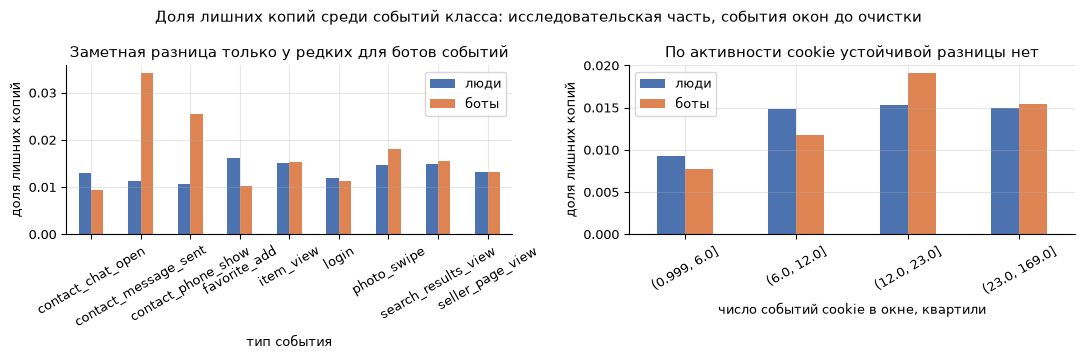

доля лишних копий по классам: {0.0: 0.0147, 1.0: 0.0156}
событий ботов по типам: {'item_view': 9629, 'search_results_view': 7820, 'photo_swipe': 1549, 'seller_page_view': 1292, 'favorite_add': 587, 'contact_phone_show': 548, 'contact_chat_open': 316, 'login': 178, 'contact_message_sent': 176}


In [11]:
# Доля лишних копий среди событий по классам, типам событий и квартилям активности cookie
target_of = meta.set_index('cookie_id')['target']
copies = in_window.assign(is_copy=is_copy.to_numpy(), target=in_window['cookie_id'].map(target_of))
copies = copies[copies['part'] == 'research']
# Квартили числа событий считаются по cookie, а не по строкам событий
activity = pd.qcut(copies.groupby('cookie_id').size(), 4)
copies['activity'] = copies['cookie_id'].map(activity)
by_type = copies.pivot_table(index='event_name', columns='target', values='is_copy')
by_activity = copies.pivot_table(
    index='activity', columns='target', values='is_copy', observed=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
panels = [(axes[0], by_type, 'тип события'),
          (axes[1], by_activity, 'число событий cookie в окне, квартили')]
for ax, table, label in panels:
    table.rename(columns={0.0: 'люди', 1.0: 'боты'}).plot.bar(ax=ax, color=[HUMAN, BOT], rot=30)
    ax.set(xlabel=label, ylabel='доля лишних копий')
    ax.legend(title=None)
axes[0].set_title('Заметная разница только у редких для ботов событий')
axes[1].set_title('По активности cookie устойчивой разницы нет')
fig.suptitle('Доля лишних копий среди событий класса: исследовательская часть, '
             'события окон до очистки')
plt.tight_layout()
plt.show()
print('доля лишних копий по классам:',
      copies.groupby('target')['is_copy'].mean().round(4).to_dict())
print('событий ботов по типам:',
      copies.loc[copies['target'] == 1, 'event_name'].value_counts().to_dict())

Лишняя копия приходится на 1.47% событий людей и 1.56% событий ботов. Высокие столбцы ботов у `contact_chat_open` и `contact_message_sent` стоят всего на 316 и 176 событиях. По квартилям активности устойчивого направления нет. Строки совпадают по всем полям, частота копий близка у классов, поэтому это повторная запись: лишнюю копию удалил

In [12]:
clean = scripts.clean_events(in_window)
key = ['cookie_id', 'event_ts', 'eid']
# После удаления полных дублей строки с общим ключом это частичные совпадения
partial = clean[clean.duplicated(subset=key, keep=False)]
value_columns = [column for column in raw_columns if column not in key]
differs_by_group = partial.groupby(key)[value_columns].nunique(dropna=False).gt(1)
differs = differs_by_group.sum()
only_platform = differs_by_group['platform'] & differs_by_group.sum(axis=1).eq(1)
print('строк с общими cookie_id, event_ts и eid:', len(partial),
      '| групп:', partial.groupby(key).ngroups)
research_clean = clean[clean['part'] == 'research']
is_partial = research_clean.duplicated(subset=key, keep=False)
print('доля событий в частичных совпадениях по классам:',
      is_partial.groupby(research_clean['cookie_id'].map(target_of)).mean().round(4).to_dict())
print('групп, где различается только написание платформы:', only_platform.sum())
differs.rename('групп, где поле различается')

строк с общими cookie_id, event_ts и eid: 740 | групп: 370
доля событий в частичных совпадениях по классам: {0.0: 0.0029, 1.0: 0.0006}
групп, где различается только написание платформы: 3


event_name         0
platform         269
user_agent        19
item_id          230
item_category    205
item_location    263
seller_type      134
search_query     118
search_page       94
pointer_x        142
pointer_y        142
Name: групп, где поле различается, dtype: int64

После удаления полных дублей остаётся 740 строк в 370 группах с общими `cookie_id`, `event_ts` и `eid`. В каждой группе различается хотя бы одно поле, чаще всего написание платформы, локация, объявление и категория, поэтому строки остаются отдельными событиями. В 3 группах различается только написание платформы, дедупликация всё равно идёт по исходным полям. У людей в такие группы попадает 0.29% событий, у ботов 0.06%

In [13]:
effect = pd.DataFrame({
    'до': in_window.groupby('part').size(), 'после': clean.groupby('part').size()})
effect['удалено'] = effect['до'] - effect['после']
effect['доля удалённых'] = (effect['удалено'] / effect['до']).round(4)
n_before = in_window.groupby('cookie_id').size()
n_after = clean.groupby('cookie_id').size().reindex(n_before.index)
type_shift = (clean['event_name'].value_counts(normalize=True)
              - in_window['event_name'].value_counts(normalize=True)).abs().max()
print('потеряно cookie:', meta['cookie_id'].nunique() - n_after.notna().sum(),
      '| изменилось число событий у cookie:', (n_before != n_after).sum())
print('максимальное изменение доли типа события:', round(type_shift, 4),
      '| ранговая корреляция n_events до и после:',
      round(n_before.corr(n_after, method='spearman'), 4))
effect

потеряно cookie: 0 | изменилось число событий у cookie: 3395
максимальное изменение доли типа события: 0.0001 | ранговая корреляция n_events до и после: 0.9992


,до,после,удалено,доля удалённых
part,,,,
holdout,35984,35441,543,0.0151
research,162452,160043,2409,0.0148
test,89690,88349,1341,0.0150


Удалено по 1.5% событий в каждой части, ни одна cookie не потеряна. Число событий изменилось у 3395 cookie, ранговая корреляция `n_events` до и после 0.9992, доли типов событий сдвинулись не больше чем на 0.0001. Для интервалов очистка важнее: каждая копия давала бы нулевой интервал

## Пропуски

Пропуск может означать, что поле неприменимо к событию, например курсор в мобильном приложении, или что ожидаемое значение не записано. Все расчёты по очищенным событиям окна

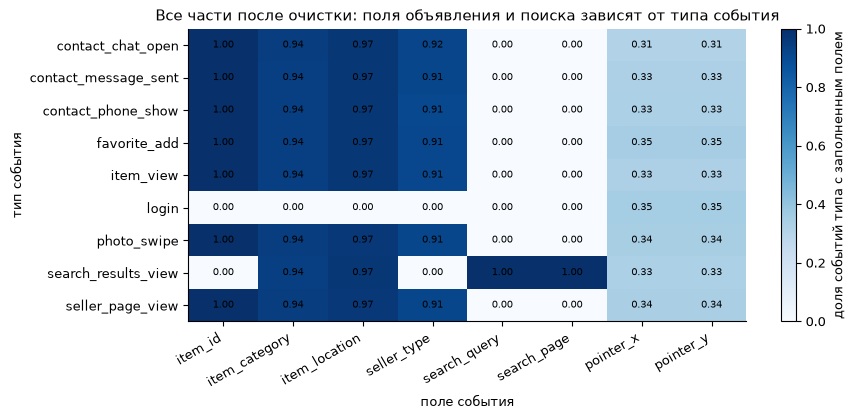

In [14]:
fields = ['item_id', 'item_category', 'item_location', 'seller_type',
          'search_query', 'search_page', 'pointer_x', 'pointer_y']
filled = clean.groupby('event_name')[fields].agg(lambda values: values.notna().mean())
fig, ax = plt.subplots(figsize=(9, 3.8))
image = ax.imshow(filled.to_numpy(), cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(fields)), fields, rotation=30, ha='right')
ax.set_yticks(range(len(filled)), filled.index)
ax.set(xlabel='поле события', ylabel='тип события')
ax.grid(False)
for (row, col), value in np.ndenumerate(filled.to_numpy()):
    ax.text(col, row, f'{value:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(image, label='доля событий типа с заполненным полем')
ax.set_title('Все части после очистки: поля объявления и поиска зависят от типа события')
plt.show()

`item_id` заполнен у всех событий с объявлением и пуст у выдачи и входа, `search_query` и `search_page` есть только у выдачи: здесь поле неприменимо к событию. Категория пуста примерно у 6% событий, где она ожидается, локация у 3%, тип продавца у 9%. Курсор заполнен у трети событий любого типа

Ниже пропуски ожидаемых значений на исследовательской части. Знаменатель это события, к которым поле применимо: категория и локация ожидаются у всех событий, кроме входа, тип продавца у событий с объявлением. `cookie_auc` это ROC-AUC доли пропусков у cookie против target

In [15]:
print('доля событий без курсора по платформам:',
      clean.groupby('platform_norm')['pointer_x'].agg(lambda values: values.isna().mean())
      .round(3).to_dict())
# Пропуск ожидаемого значения: поле применимо к событию, но пусто. Только исследовательская часть
research_events = clean[clean['part'] == 'research']
event_target = research_events['cookie_id'].map(target_of)
expected = {
    'item_category': research_events['event_name'] != 'login',
    'item_location': research_events['event_name'] != 'login',
    'seller_type': research_events['item_id'].notna(),
}
rows = {}
for field, applies in expected.items():
    events_with_field = research_events[applies]
    missing = events_with_field[field].isna()
    by_type = missing.groupby(events_with_field['event_name']).mean()
    by_day = missing.groupby(events_with_field['window_start_ts']).mean()
    share_per_cookie = missing.groupby(events_with_field['cookie_id']).mean().rename('share')
    rows[field] = {
        'events': len(missing), 'humans': missing[event_target[applies] == 0].mean(),
        'bots': missing[event_target[applies] == 1].mean(),
        'type_min': by_type.min(), 'type_max': by_type.max(),
        'day_min': by_day.min(), 'day_max': by_day.max(),
        'cookie_auc': scripts.feature_auc(share_per_cookie.to_frame().join(target_of), 'share'),
    }
pd.DataFrame(rows).T.round(4)

доля событий без курсора по платформам: {'android': 1.0, 'ios': 1.0, 'web': 0.407}


,events,humans,bots,type_min,type_max,day_min,day_max,cookie_auc
item_category,156864.0,0.0602,0.0625,0.0577,0.0638,0.0554,0.0636,0.5515
item_location,156864.0,0.0304,0.0308,0.0279,0.0333,0.0289,0.0318,0.5635
seller_type,107063.0,0.0919,0.0885,0.0850,0.0977,0.0891,0.0947,0.5266


Доля пропусков на событие почти одинакова у людей и ботов, по типам событий и по дням: категория 0.0602 и 0.0625, локация 0.0304 и 0.0308, тип продавца 0.0919 и 0.0885. Доля пропусков у cookie связана с target слабо, AUC от 0.53 до 0.56, поэтому в первый набор индикаторы пропуска не включил

Курсора на android и ios нет никогда, у мобильных cookie его статистики не определены, а не равны нулю. На web координат нет у 40.7% событий, это разобрано в разделе «Курсор»

Платформа записана 11 значениями. Написания сопоставил по ОС в User-Agent и совместной встречаемости внутри cookie

In [16]:
user_agent = clean['user_agent']
ua_os = np.select(
    [user_agent.str.contains('Android'), user_agent.str.contains('iPhone'),
     user_agent.str.contains('Windows|Macintosh|X11')],
    ['Android', 'iOS', 'настольная ОС'], 'ОС не указана')
pd.crosstab(clean['platform'], ua_os)

col_0,Android,iOS,ОС не указана,настольная ОС
platform,,,,
ANDROID,37013,0,0,0
Android,36802,0,0,0
IOS,0,3589,0,0
WEB,0,0,1398,38342
Web,0,0,1477,38212
android,36741,0,0,0
desktop,0,0,1496,38663
iOS,0,3593,0,0
ios,0,3600,0,0


User-Agent согласован с платформой. У WEB, Web, web и desktop одинаковый набор настольных ОС и строки без ОС, у IOS, iOS, ios и iphone только iOS, у трёх вариантов android только Android

In [17]:
spellings = clean.groupby('cookie_id')['platform'].agg(
    lambda values: ', '.join(sorted(values.unique())))
print('нормализованных платформ на cookie:',
      clean.groupby('cookie_id')['platform_norm'].nunique().value_counts().to_dict())
spellings.value_counts().head(6).rename('cookie')

нормализованных платформ на cookie: {1: 16000}


platform
WEB, Web, desktop, web       5998
ANDROID, Android, android    5358
IOS, iOS, ios, iphone         580
WEB, Web, desktop             420
Web, desktop, web             393
WEB, desktop, web             379
Name: cookie, dtype: int64

Внутри одной cookie эти значения чередуются: у 5998 cookie встречаются все три написания web вместе с desktop, у 580 все три написания ios вместе с iphone. После нормализации у каждой из 16000 cookie ровно одна платформа. Поэтому desktop объединил с web, а iphone с ios

In [18]:
# Число разных написаний у cookie: ограничено набором платформы и растёт с числом событий
per_cookie = clean.groupby('cookie_id').agg(
    platform=('platform_norm', 'first'), spellings=('platform', 'nunique'),
    events=('event_ts', 'size'))
events_bin = pd.cut(per_cookie['events'], [0, 2, 5, 10, 20, 200])
spelling_table = pd.crosstab(
    per_cookie['platform'], events_bin, values=per_cookie['spellings'], aggfunc='mean')
spelling_table.round(2)

events,"(0, 2]","(2, 5]","(5, 10]","(10, 20]","(20, 200]"
platform,,,,,
android,1.40,2.37,2.86,2.99,3.0
ios,1.42,2.82,3.57,3.93,4.0
web,1.47,2.70,3.56,3.92,4.0


Число разных написаний у cookie растёт с числом событий и упирается в размер набора: три у android и четыре у web и ios. Это свойство записи, а не поведения, в признаки его не взял

In [19]:
distinct_ua = clean.drop_duplicates('user_agent')
ua_table = distinct_ua.groupby('ua_kind')['user_agent'].agg(['size', 'first'])
ua_table.columns = ['разных строк', 'пример']
kinds_per_cookie = clean.groupby('cookie_id')['ua_kind'].nunique()
assert kinds_per_cookie.max() == 1
train_ua = set(clean.loc[clean['part'] != 'test', 'user_agent'])
test_ua = set(clean.loc[clean['part'] == 'test', 'user_agent'])
print('строк User-Agent:', user_agent.nunique(),
      '| есть в test, но нет в train:', len(test_ua - train_ua))
print(pd.crosstab(per_cookie['platform'], clean.groupby('cookie_id')['ua_kind'].first()))
ua_table

строк User-Agent: 148 | есть в test, но нет в train: 0
ua_kind    app  browser  headless  http_lib
platform                                   
android   2470     4116         0         0
ios        565      269         0         0
web          0     7887       421       272


,разных строк,пример
ua_kind,,
app,33,Avito/118.0 (Android 11; M2101K6G) okhttp/4.11.0
browser,105,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...
headless,4,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...
http_lib,6,node-fetch/3.3.2


В 148 строках User-Agent четыре вида клиентов: 105 браузерных строк, 33 строки приложения Avito, 4 версии HeadlessChrome и 6 HTTP-библиотек вроде python-requests, Scrapy, curl и node-fetch. У каждой cookie один вид клиента. Приложение встречается только на android и ios, headless и HTTP-библиотеки только на web

Все строки User-Agent из test встречаются в train. Для основного набора выбрал вид клиента, сырую строку проверил отдельной гипотезой

## Поведение

In [20]:
features = scripts.cookie_features(clean, meta)
frame = features.join(meta.set_index('cookie_id')[['target', 'part', 'window_start_ts']])
frame['day'] = frame['window_start_ts'].dt.strftime('%m-%d')
research = frame[frame['part'] == 'research']
base_rate = research['target'].mean()
print('таблица агрегатов:', features.shape, '| исследовательская часть:', research.shape,
      '| доля ботов:', round(base_rate, 4))
# Нулевой счётчик означает «событий не было», NaN означает «статистика не определена»
undefined = features.isna().sum()
undefined[undefined > 0].rename('cookie с NaN')

таблица агрегатов: (16000, 28) | исследовательская часть: (9140, 32) | доля ботов: 0.0809


gap_median_s         359
gap_cv               951
share_gap_le_1s      359
page_mean           1356
page_max            1356
pointer_share       7420
pointer_std_x      10309
pointer_std_y      10309
Name: cookie с NaN, dtype: int64

Получилось 28 агрегатов на 16000 cookie. Счётчики определены у всех и равны нулю, если событий не было. NaN означает, что статистика не определена: интервалов нет у 359 cookie с одним событием, коэффициент вариации интервалов не определён у 951 cookie, глубины выдачи нет у 1356 cookie без поиска, курсора нет у мобильных cookie и у web cookie без координат

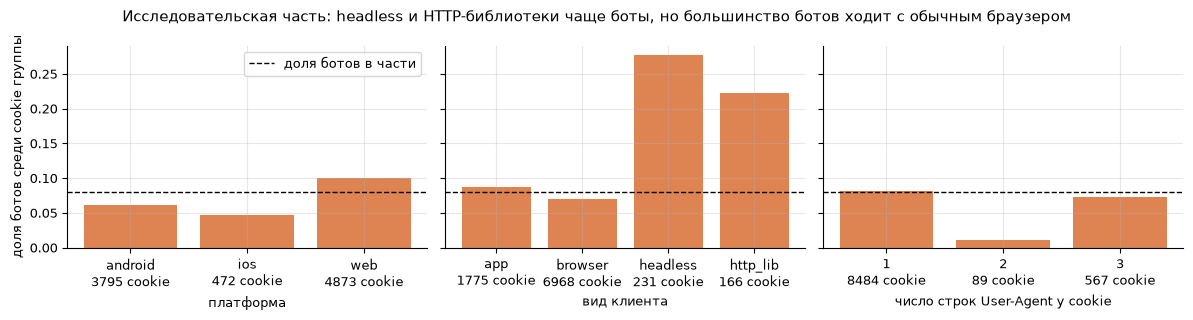

cookies   bots  bot_share
platform      android      3795  231.0      0.061
              ios           472   22.0      0.047
              web          4873  486.0      0.100
ua_kind       app          1775  154.0      0.087
              browser      6968  484.0      0.069
              headless      231   64.0      0.277
              http_lib      166   37.0      0.223
n_user_agents 1            8484  697.0      0.082
              2              89    1.0      0.011
              3             567   41.0      0.072

In [21]:
client = pd.concat({
    column: research.groupby(column)['target'].agg(cookies='size', bots='sum', bot_share='mean')
    for column in ['platform', 'ua_kind', 'n_user_agents']})
client_names = {'platform': 'платформа', 'ua_kind': 'вид клиента',
                'n_user_agents': 'число строк User-Agent у cookie'}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, column in zip(axes, client_names):
    part = client.loc[column]
    labels = [f'{value}\n{int(cookies)} cookie' for value, cookies in part['cookies'].items()]
    ax.bar(labels, part['bot_share'], color=BOT)
    ax.axhline(base_rate, color='black', ls='--', lw=1, label='доля ботов в части')
    ax.set_xlabel(client_names[column])
axes[0].set_ylabel('доля ботов среди cookie группы')
axes[0].legend()
fig.suptitle('Исследовательская часть: headless и HTTP-библиотеки чаще боты, '
             'но большинство ботов ходит с обычным браузером')
plt.tight_layout()
plt.show()
client.round(3)

HeadlessChrome даёт 27.7% ботов, HTTP-библиотеки 22.3%, втрое выше доли 0.081 по части, но 484 из 739 ботов ходят с обычным браузером. Правило, которое отмечает всех headless, нашло бы 64 бота из 739 с precision 0.277, поэтому вид клиента может быть только одним из признаков. На web ботов 10.0%, на android 6.1%, на ios 4.7%. Две строки User-Agent встречаются у 89 cookie, из них один бот

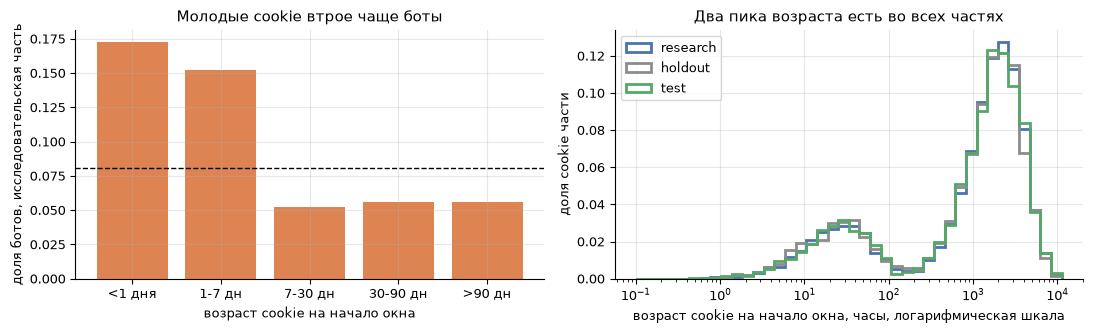

,cookies,bots,bot_share
cookie_age_h,,,
<1 дня,1058,183.0,0.173
1-7 дн,1089,166.0,0.152
7-30 дн,765,40.0,0.052
30-90 дн,3166,178.0,0.056
>90 дн,3062,172.0,0.056


In [22]:
age_bins = pd.cut(research['cookie_age_h'], [0, 24, 24 * 7, 24 * 30, 24 * 90, 24 * 500],
                  labels=['<1 дня', '1-7 дн', '7-30 дн', '30-90 дн', '>90 дн'],
                  include_lowest=True)
by_age = research.groupby(age_bins, observed=True)['target'].agg(
    cookies='size', bots='sum', bot_share='mean')
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(by_age.index.astype(str), by_age['bot_share'], color=BOT)
axes[0].axhline(base_rate, color='black', ls='--', lw=1)
axes[0].set(xlabel='возраст cookie на начало окна', ylabel='доля ботов, исследовательская часть',
            title='Молодые cookie втрое чаще боты')
# Общие логарифмические корзины для всех частей, чтобы доли были прямо сопоставимы
age_edges = np.logspace(-1, np.log10(frame['cookie_age_h'].max() * 1.01), 41)
for part, color in PART_COLORS.items():
    part_age = frame.loc[frame['part'] == part, 'cookie_age_h']
    weights = np.full(len(part_age), 1 / len(part_age))
    axes[1].hist(part_age, bins=age_edges, weights=weights,
                 histtype='step', lw=2, color=color, label=part)
axes[1].set_xscale('log')
axes[1].set(xlabel='возраст cookie на начало окна, часы, логарифмическая шкала',
            ylabel='доля cookie части', title='Два пика возраста есть во всех частях')
axes[1].legend()
plt.tight_layout()
plt.show()
by_age.round(3)

Cookie моложе недели примерно втрое чаще боты: 17.3% у созданных меньше суток назад и 15.2% у созданных за 1-7 дней против 5.2-5.6% у более старых. У всех трёх частей два пика возраста, около суток и около трёх месяцев, и доли по корзинам близки. Возраст считается от начала окна по метаданным и известен к его концу

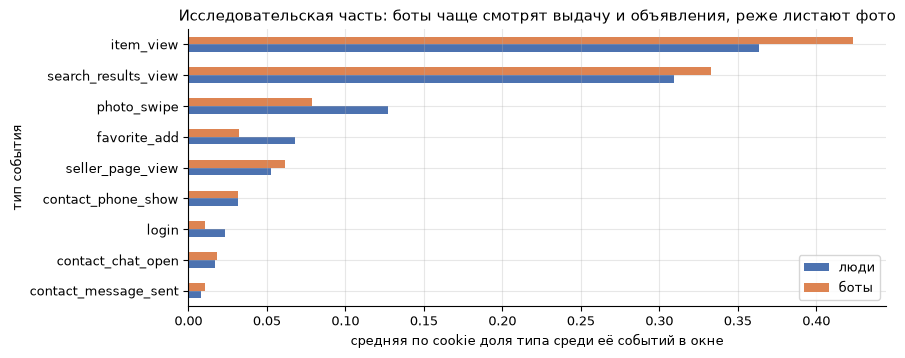

In [23]:
# Состав действий: средняя доля каждого типа события у cookie
type_columns = ['n_' + name for name in sorted(clean['event_name'].unique())]
shares = research[type_columns].div(research['n_events'], axis=0)
composition = shares.groupby(research['target']).mean().T
composition = composition.rename(columns={0.0: 'люди', 1.0: 'боты'})
composition.index = composition.index.str.removeprefix('n_')
ax = composition.sort_values('люди').plot.barh(color=[HUMAN, BOT], figsize=(9, 3.6))
ax.legend(title=None)
ax.set(xlabel='средняя по cookie доля типа среди её событий в окне', ylabel='тип события',
       title='Исследовательская часть: боты чаще смотрят выдачу и объявления, реже листают фото')
plt.show()

Боты чаще смотрят объявления и выдачу, реже листают фото, добавляют в избранное и входят в аккаунт. Контактные действия у классов почти одинаковы. Доля типа события описывает, чем занят клиент, и дополняет счётчики объёма

В таблице AUC каждого агрегата на всей исследовательской части и его диапазон по 11 дням. AUC ниже 0.5 означает, что у ботов значение меньше. Одномерный AUC показывает силу и направление связи по отдельности, без взаимодействий и повторов между признаками

In [24]:
numeric = [column for column in features.columns if column not in ('platform', 'ua_kind')]
signals = scripts.signal_table(research, numeric)
signals['distance_from_05'] = (signals['auc'] - 0.5).abs()
signals.sort_values('distance_from_05', ascending=False).round(3)

,cookies,auc,auc_day_min,auc_day_max,distance_from_05
pointer_std_x,3233,0.060,0.022,0.131,0.440
pointer_std_y,3233,0.178,0.104,0.245,0.322
gap_median_s,8928,0.271,0.180,0.343,0.229
page_mean,8389,0.723,0.644,0.791,0.223
page_max,8389,0.718,0.659,0.761,0.218
n_locations,9140,0.715,0.647,0.761,0.215
max_events_per_min,9140,0.698,0.647,0.772,0.198
n_item_view,9140,0.688,0.629,0.733,0.188
n_items,9140,0.671,0.598,0.726,0.171
n_events,9140,0.669,0.605,0.723,0.169


Сильнее всего разделяет разброс курсора, он есть только у 3233 web cookie. Среди остальных выделяются медианный интервал между событиями (0.271), средняя страница выдачи (0.723), число локаций (0.715), пик событий за минуту (0.698), число просмотров объявлений (0.688) и возраст cookie (0.371). Контактные действия, фото, вход и число строк User-Agent почти не связаны с target. Одиночного признака, который разделял бы классы на всех cookie, нет

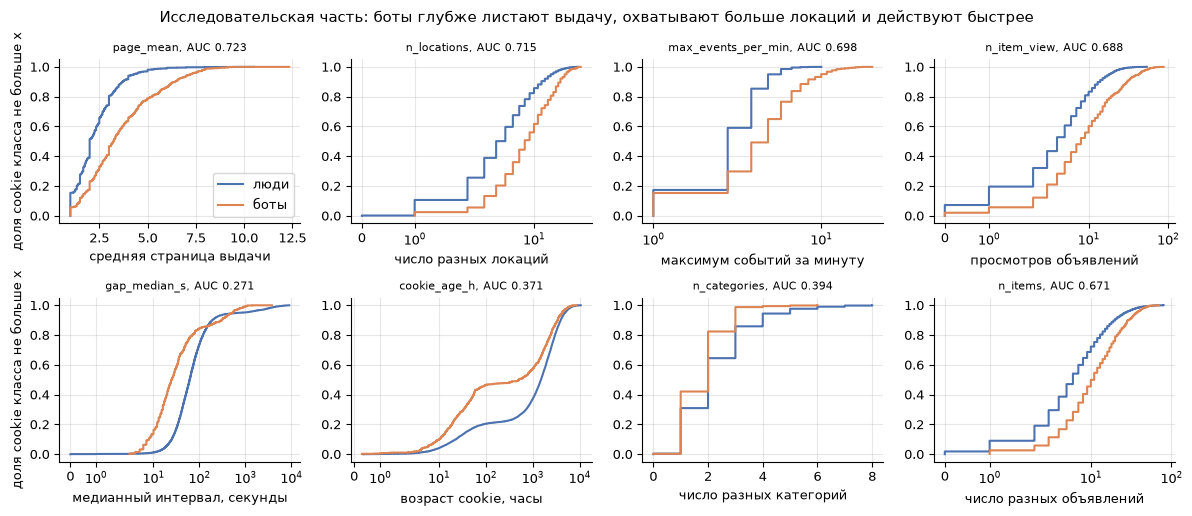

In [25]:
axis_names = {
    'page_mean': 'средняя страница выдачи', 'n_locations': 'число разных локаций',
    'max_events_per_min': 'максимум событий за минуту', 'n_item_view': 'просмотров объявлений',
    'gap_median_s': 'медианный интервал, секунды', 'cookie_age_h': 'возраст cookie, часы',
    'n_categories': 'число разных категорий', 'n_items': 'число разных объявлений',
}
shown = list(axis_names)
fig, axes = plt.subplots(2, 4, figsize=(12, 5.2))
for ax, name in zip(axes.flat, shown):
    for label, color in [(0.0, HUMAN), (1.0, BOT)]:
        values = np.sort(research.loc[research['target'] == label, name].dropna())
        # Эмпирическая функция распределения не требует выбора интервалов гистограммы
        ax.step(values, np.arange(1, len(values) + 1) / len(values), color=color,
                label='боты' if label else 'люди')
    # Логарифмическая шкала только для широких диапазонов, мелкие счётчики остаются линейными
    if research[name].max() > 20:
        ax.set_xscale('symlog')
    ax.set_title(f'{name}, AUC {signals.loc[name, "auc"]:.3f}', fontsize=8)
    ax.set_xlabel(axis_names[name])
for ax in axes[:, 0]:
    ax.set_ylabel('доля cookie класса не больше x')
axes[0, 0].legend()
fig.suptitle('Исследовательская часть: боты глубже листают выдачу, '
             'охватывают больше локаций и действуют быстрее')
plt.tight_layout()
plt.show()

У ботов глубже выдача, больше локаций и объявлений, выше пик событий за минуту, короче медианный интервал и моложе cookie, кривые расходятся на большей части диапазона. У интервалов у ботов есть и длинный хвост, поэтому в эксперимент взял несколько статистик ритма, а не одну медиану

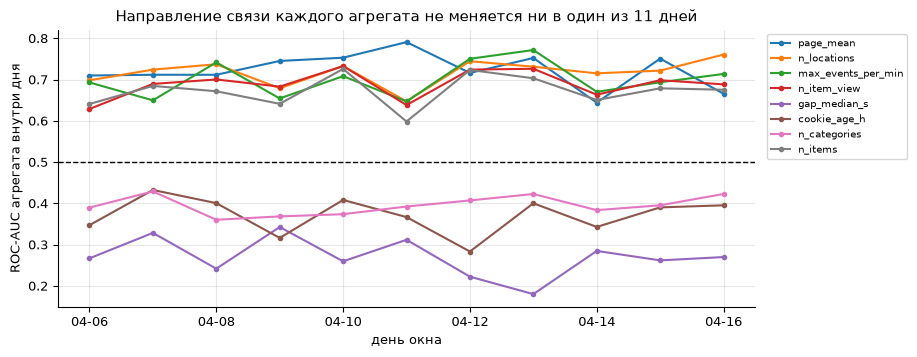

,page_mean,n_locations,max_events_per_min,n_item_view,gap_median_s,cookie_age_h,n_categories,n_items
min,0.644,0.647,0.647,0.629,0.180,0.283,0.360,0.598
max,0.791,0.761,0.772,0.733,0.343,0.432,0.429,0.726


In [26]:
by_day = scripts.daily_auc(research, shown)
ax = by_day.plot(figsize=(9, 3.6), marker='o', ms=3)
ax.axhline(0.5, color='black', ls='--', lw=1)
ax.set(xlabel='день окна', ylabel='ROC-AUC агрегата внутри дня',
       title='Направление связи каждого агрегата не меняется ни в один из 11 дней')
ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.show()
by_day.agg(['min', 'max']).round(3)

По дням AUC каждого агрегата колеблется, но ни разу не переходит через 0.5: средняя страница выдачи от 0.644 до 0.791, медианный интервал от 0.180 до 0.343, возраст cookie от 0.283 до 0.432. Направление связей держится во всех днях

## Курсор

У разброса `pointer_x` AUC 0.060, но он определён только у части web cookie

web cookie: 4873 | с двумя и более координатами: 3233 | из них по классам: {0.0: 3028, 1.0: 205}


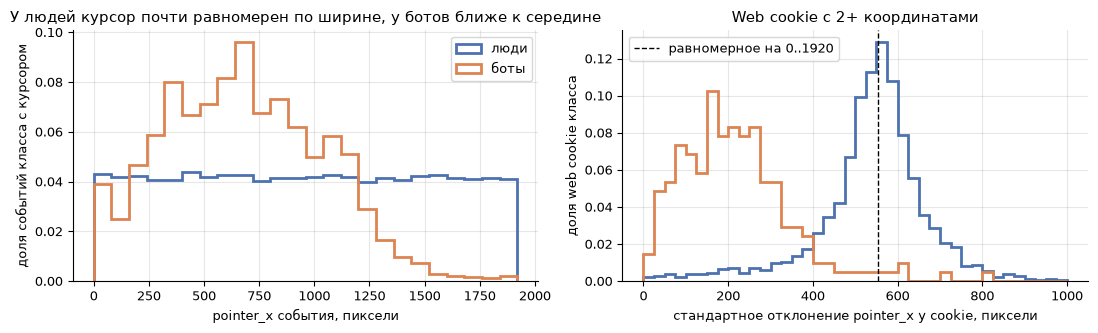

разброс равномерного распределения на 1920 точках: 554.3
{0.0: 553.0, 1.0: 201.7}


In [27]:
pointer_events = clean[clean['pointer_x'].notna() & (clean['part'] == 'research')]
pointer_target = pointer_events['cookie_id'].map(target_of)
web = research[research['platform'] == 'web']
# Стандартное отклонение определено только у cookie с двумя и более координатами
eligible = web['pointer_std_x'].notna()
print('web cookie:', len(web), '| с двумя и более координатами:', eligible.sum(),
      '| из них по классам:', eligible.groupby(web['target']).sum().to_dict())
uniform_std = scripts.SCREEN_W / np.sqrt(12)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for label, color in [(0.0, HUMAN), (1.0, BOT)]:
    xs = pointer_events.loc[pointer_target == label, 'pointer_x']
    axes[0].hist(xs, bins=np.linspace(0, 1920, 25), weights=np.full(len(xs), 1 / len(xs)),
                 histtype='step', lw=2, color=color, label='боты' if label else 'люди')
    stds = web.loc[web['target'] == label, 'pointer_std_x'].dropna()
    axes[1].hist(stds, bins=np.linspace(0, 1000, 41), weights=np.full(len(stds), 1 / len(stds)),
                 histtype='step', lw=2, color=color)
axes[0].set(xlabel='pointer_x события, пиксели', ylabel='доля событий класса с курсором',
            title='У людей курсор почти равномерен по ширине, у ботов ближе к середине')
axes[1].axvline(uniform_std, color='black', ls='--', lw=1, label='равномерное на 0..1920')
axes[1].set(xlabel='стандартное отклонение pointer_x у cookie, пиксели',
            ylabel='доля web cookie класса', title='Web cookie с 2+ координатами')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()
print('разброс равномерного распределения на 1920 точках:', round(uniform_std, 1))
print(web.groupby('target')['pointer_std_x'].median().round(1).to_dict())

Стандартное отклонение pointer_x определено у 3233 из 4873 web cookie исследовательской части, у которых есть хотя бы две координаты. У людей pointer_x распределён почти равномерно по ширине от 0 до 1920 пикселей, медианное отклонение 553.0 при 554.3 у равномерного распределения. У ботов координаты ближе к середине, медианное отклонение 201.7

In [28]:
presence = pd.cut(web['pointer_share'], [-0.01, 0, 0.5, 0.99, 1],
                  labels=['нет курсора', 'до половины', 'больше половины', 'у всех событий'])
print('web cookie по наличию курсора, исследовательская часть')
by_presence = web.groupby(presence, observed=True)['target'].agg(
    cookies='size', bots='sum', bot_share='mean')
print(by_presence.round(3))
low_spread = frame['pointer_std_x'] < 200
print('доля web cookie с разбросом курсора меньше 200 по частям:',
      low_spread[frame['pointer_std_x'].notna()].groupby(frame['part']).mean().round(3).to_dict())

web cookie по наличию курсора, исследовательская часть
                 cookies   bots  bot_share
pointer_share                             
нет курсора         1533  280.0      0.183
до половины           31    0.0      0.000
больше половины     1576  124.0      0.079
у всех событий      1733   82.0      0.047
доля web cookie с разбросом курсора меньше 200 по частям: {'holdout': 0.061, 'research': 0.059, 'test': 0.079}


Отсутствие курсора на web тоже связано с target: 18.3% ботов среди 1533 web cookie без единой координаты против 4.7% у cookie, где курсор есть у всех событий. Доля web cookie с отклонением меньше 200 пикселей 0.059 в исследовательской части, 0.061 в отложенном блоке и 0.079 в test

Наличие и разброс курсора включил отдельной гипотезой. Координаты доступны внутри окна только на web, проверить их связь с процедурой разметки по этим данным нельзя

## Связи признаков

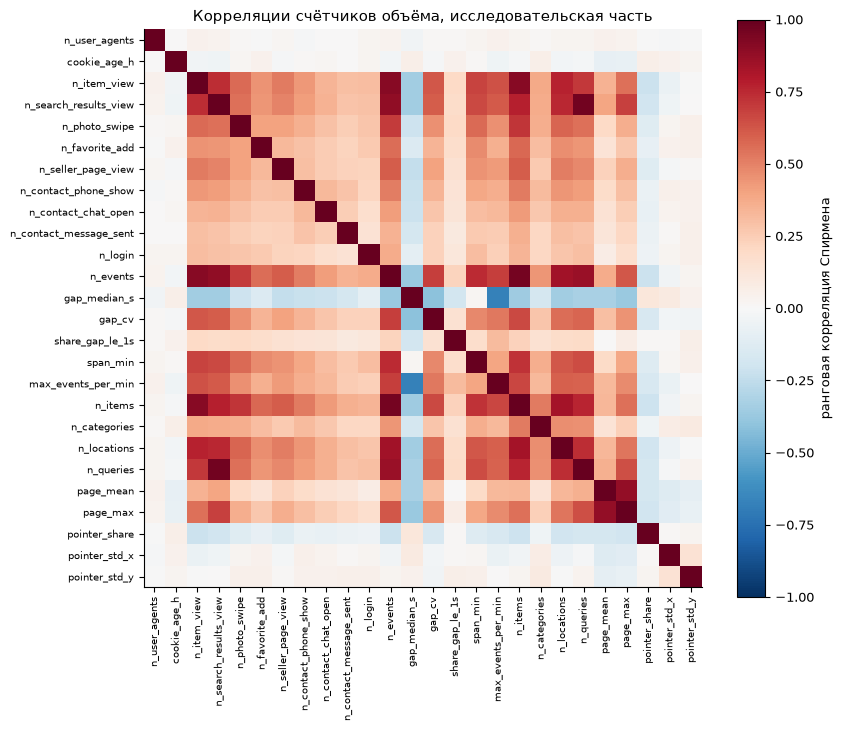

n_search_results_view  n_queries    0.964
n_events               n_items      0.960
n_item_view            n_events     0.914
                       n_items      0.912
n_search_results_view  n_events     0.889
page_mean              page_max     0.881
n_events               n_queries    0.861
Name: rho, dtype: float64

In [29]:
corr = research[numeric].corr(method='spearman')
fig, ax = plt.subplots(figsize=(9, 7.5))
image = ax.imshow(corr.to_numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric)), numeric, rotation=90, fontsize=7)
ax.set_yticks(range(len(numeric)), numeric, fontsize=7)
ax.grid(False)
fig.colorbar(image, label='ранговая корреляция Спирмена')
ax.set_title('Корреляции счётчиков объёма, исследовательская часть')
plt.show()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack()
upper[upper.abs() >= 0.85].sort_values(ascending=False).round(3).rename('rho')

Счётчики объёма образуют один блок: число выдач и число запросов связаны на 0.964, число событий и объявлений на 0.960, просмотры объявлений и число событий на 0.914, средняя и максимальная страница на 0.881. Медианный интервал отрицательно связан с пиком событий за минуту. Курсор, возраст cookie и число строк User-Agent почти не связаны с объёмом. Добавочную пользу второго счётчика из одного блока проверит эксперимент

In [30]:
# Вырожденность: доля самого частого значения и доля неопределённых значений
most_common = research[numeric].apply(
    lambda values: values.value_counts(normalize=True, dropna=False).iloc[0])
degenerate = pd.DataFrame({
    'top_value_share': most_common, 'nan_share': research[numeric].isna().mean()})
print('типы событий внутри окон:', sorted(clean['event_name'].unique()))
degenerate[(degenerate['top_value_share'] > 0.9) | (degenerate['nan_share'] > 0.5)].round(3)

типы событий внутри окон: ['contact_chat_open', 'contact_message_sent', 'contact_phone_show', 'favorite_add', 'item_view', 'login', 'photo_swipe', 'search_results_view', 'seller_page_view']


,top_value_share,nan_share
n_user_agents,0.928,0.000
pointer_std_x,0.646,0.646
pointer_std_y,0.646,0.646


Капчи внутри окон нет, поэтому счётчика капчи в таблице нет. У 92.8% cookie одна строка User-Agent, признак почти постоянный. Разброс курсора не определён у 64.6% cookie

## Распределения по дням

Доля ботов показана только для 04-06..04-16, остальные распределения сравниваются по всем частям

In [31]:
volume = frame.groupby('part', sort=False).agg(
    cookies=('n_events', 'size'), days=('day', 'nunique'))
volume['cookies_per_day'] = (volume['cookies'] / volume['days']).round(1)
research_level = volume.loc['research', 'cookies_per_day']
volume['change_vs_research'] = (volume['cookies_per_day'] / research_level - 1).round(3)
volume

,cookies,days,cookies_per_day,change_vs_research
part,,,,
research,9140,11,830.9,0.000
holdout,1951,3,650.3,-0.217
test,4909,7,701.3,-0.156


В исследовательской части в среднем 830.9 cookie в день, в отложенном блоке 650.3 и в test 701.3, то есть на 21.7% и 15.6% меньше. Объём к концу периода ниже

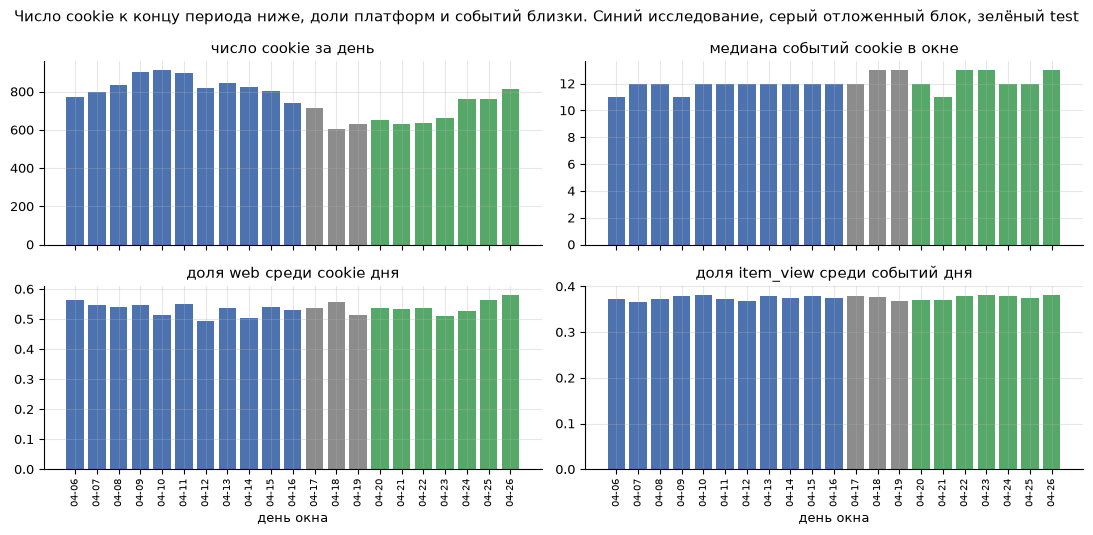

,part,cookies,median_events,web_share,browser_share,median_age_h,bot_share,share_item_view,share_search_results_view,share_photo_swipe
day,,,,,,,,,,
04-06,research,772,11.0,0.563,0.784,1421.324,0.088,0.373,0.309,0.116
04-07,research,797,12.0,0.548,0.760,1387.867,0.074,0.367,0.312,0.119
04-08,research,834,12.0,0.541,0.758,1467.448,0.084,0.372,0.306,0.120
04-09,research,902,11.0,0.548,0.759,1526.356,0.073,0.378,0.306,0.114
04-10,research,912,12.0,0.513,0.735,1386.547,0.090,0.380,0.315,0.113
04-11,research,896,12.0,0.551,0.775,1363.596,0.088,0.373,0.314,0.115
04-12,research,817,12.0,0.492,0.767,1452.178,0.082,0.367,0.312,0.115
04-13,research,843,12.0,0.537,0.741,1454.317,0.063,0.378,0.321,0.113
04-14,research,826,12.0,0.502,0.753,1532.800,0.085,0.374,0.305,0.117


In [32]:
daily = frame.groupby('day').agg(
    part=('part', 'first'), cookies=('n_events', 'size'), median_events=('n_events', 'median'),
    web_share=('platform', lambda values: values.eq('web').mean()),
    browser_share=('ua_kind', lambda values: values.eq('browser').mean()),
    median_age_h=('cookie_age_h', 'median'), bot_share=('target', 'mean'))
event_day = clean['window_start_ts'].dt.strftime('%m-%d')
event_mix = pd.crosstab(event_day, clean['event_name'], normalize='index')
main_types = ['item_view', 'search_results_view', 'photo_swipe']
daily = daily.join(event_mix[main_types].add_prefix('share_'))
fig, axes = plt.subplots(2, 2, figsize=(11, 5.4), sharex=True)
panels = [('cookies', 'число cookie за день'), ('median_events', 'медиана событий cookie в окне'),
          ('web_share', 'доля web среди cookie дня'),
          ('share_item_view', 'доля item_view среди событий дня')]
for ax, (column, title) in zip(axes.flat, panels):
    ax.bar(daily.index, daily[column], color=daily['part'].map(PART_COLORS))
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90, labelsize=7)
for ax in axes[1]:
    ax.set_xlabel('день окна')
fig.suptitle('Число cookie к концу периода ниже, доли платформ и событий близки. '
             'Синий исследование, серый отложенный блок, зелёный test')
plt.tight_layout()
plt.show()
daily.round(3)

Доли платформ и событий по дням близки: web от 0.492 до 0.581, браузеры от 0.735 до 0.800, `item_view` от 0.367 до 0.381, медиана событий у cookie 11-13. Доля ботов в исследовательских днях от 0.063 до 0.090. Проверочные дни оставил без перебалансировки

## Валидация

Сценарий test: модель обучена на прошлых днях и оценивает следующую неделю одним списком. В исследовательской части 11 дней и около 67 ботов в день. Проверочный блок должен состоять из нескольких целых дней, иначе ботов в нём слишком мало для метрики на уровне recall 0.70

In [33]:
# Даты и состав разбиений берутся из scripts.FOLDS и fold_cookies
folds = scripts.fold_cookies(meta)
rows = []
for fold, parts in folds.items():
    for role, ids in parts.items():
        part = frame.loc[ids]
        days = pd.Series(sorted(part['window_start_ts'].unique()))
        bots = int(part['target'].sum())
        rows.append({
            'fold': fold, 'part': role, 'days': f'{days.iloc[0]:%m-%d}..{days.iloc[-1]:%m-%d}',
            'weekdays': ' '.join(days.dt.day_name().str[:3]), 'cookies': len(part), 'bots': bots,
            'bot_share': round(bots / len(part), 4),
            'bots_for_recall_07': int(np.ceil(0.7 * bots)) if role == 'valid' else np.nan,
        })
fold_sizes = pd.DataFrame(rows).set_index(['fold', 'part'])
# Число cookie и ботов в каждом разбиении
expected = {('fold_a', 'train'): (3305, 263), ('fold_a', 'valid'): (2625, 228),
            ('fold_b', 'train'): (5930, 491), ('fold_b', 'valid'): (3210, 248)}
assert {key: (row.cookies, row.bots) for key, row in fold_sizes.iterrows()} == expected
fold_sizes

days                     weekdays  cookies  bots  bot_share  bots_for_recall_07
fold   part                                                                                          
fold_a train  04-06..04-09              Mon Tue Wed Thu     3305   263     0.0796                 NaN
       valid  04-10..04-12                  Fri Sat Sun     2625   228     0.0869               160.0
fold_b train  04-06..04-12  Mon Tue Wed Thu Fri Sat Sun     5930   491     0.0828                 NaN
       valid  04-13..04-16              Mon Tue Wed Thu     3210   248     0.0773               174.0

Разбиения заданы в `scripts.FOLDS`. `fold_a` учится на понедельнике-четверге 04-06..04-09 и проверяется на пятнице-воскресенье 04-10..04-12, `fold_b` учится на 04-06..04-12 и проверяется на понедельнике-четверге 04-13..04-16. Вместе проверочные дни покрывают каждый день недели один раз, как test. В проверке 228 и 248 ботов, для recall 0.70 нужно найти 160 и 174 из них

In [34]:
valid_ids = folds['fold_a']['valid'].union(folds['fold_b']['valid'])
only_train = research.index.difference(valid_ids)
fold_ids = valid_ids.union(folds['fold_b']['train'])
print('cookie в проверке двух разбиений:', len(valid_ids),
      '| ботов:', int(research.loc[valid_ids, 'target'].sum()))
print('cookie исследовательской части только в обучении:', len(only_train),
      '| это обучение fold_a:', only_train.equals(folds['fold_a']['train']))
print('строка признаков на каждую cookie meta в том же порядке:',
      features.index.equals(pd.Index(meta['cookie_id'])),
      '| cookie разбиений без строки признаков:', len(fold_ids.difference(features.index)))

cookie в проверке двух разбиений: 5835 | ботов: 476
cookie исследовательской части только в обучении: 3305 | это обучение fold_a: True
строка признаков на каждую cookie meta в том же порядке: True | cookie разбиений без строки признаков: 0


Два проверочных блока вместе дают 5835 разных cookie и 476 ботов. Остальные 3305 cookie исследовательской части это ровно обучение `fold_a`, проверочных предсказаний они не получают. В таблице признаков строка на каждую cookie в порядке meta, поэтому выбор признаков по cookie_id разбиения ничего не теряет

In [35]:
# Знаменатель указан в имени строки: cookie части, события части или web cookie части
profile = {}
for fold, parts in folds.items():
    for role, ids in parts.items():
        part = frame.loc[ids]
        web = part[part['platform'] == 'web']
        profile[(fold, role)] = {
            'web_of_cookies': (part['platform'] == 'web').mean(),
            'android_of_cookies': (part['platform'] == 'android').mean(),
            'ios_of_cookies': (part['platform'] == 'ios').mean(),
            'headless_or_http_lib_of_cookies':
                part['ua_kind'].isin(['headless', 'http_lib']).mean(),
            'item_view_of_events': part['n_item_view'].sum() / part['n_events'].sum(),
            'search_of_events': part['n_search_results_view'].sum() / part['n_events'].sum(),
            'median_events_per_cookie': part['n_events'].median(),
            'cookies_with_1_5_events': (part['n_events'] <= 5).mean(),
            'median_cookie_age_h': part['cookie_age_h'].median(),
            'cookies_younger_7d': (part['cookie_age_h'] < 24 * 7).mean(),
            'cookies_without_search': part['page_mean'].isna().mean(),
            'web_cookies_without_pointer': (web['pointer_share'] == 0).mean(),
        }
pd.DataFrame(profile).round(3)

fold_a              fold_b          
                                    train     valid     train     valid
web_of_cookies                      0.550     0.520     0.536     0.527
android_of_cookies                  0.394     0.427     0.409     0.427
ios_of_cookies                      0.056     0.053     0.055     0.045
headless_or_http_lib_of_cookies     0.038     0.044     0.041     0.049
item_view_of_events                 0.373     0.374     0.373     0.377
search_of_events                    0.308     0.314     0.311     0.312
median_events_per_cookie           12.000    12.000    12.000    12.000
cookies_with_1_5_events             0.215     0.213     0.214     0.213
median_cookie_age_h              1438.820  1391.242  1421.042  1493.628
cookies_younger_7d                  0.238     0.241     0.239     0.226
cookies_without_search              0.083     0.082     0.083     0.081
web_cookies_without_pointer         0.326     0.303     0.316     0.312

Состав частей близок. Доля web среди cookie части от 0.520 до 0.550, android от 0.394 до 0.427, доли `item_view` и выдачи среди событий части различаются меньше чем на 0.01, медиана событий у cookie везде 12. Доля ботов 0.0796 в обучении `fold_a`, 0.0869 в его проверке и 0.0773 в проверке `fold_b`. Возраст cookie, доля cookie младше недели, доля cookie без поиска и доля web cookie без курсора тоже близки. Это естественные различия дней

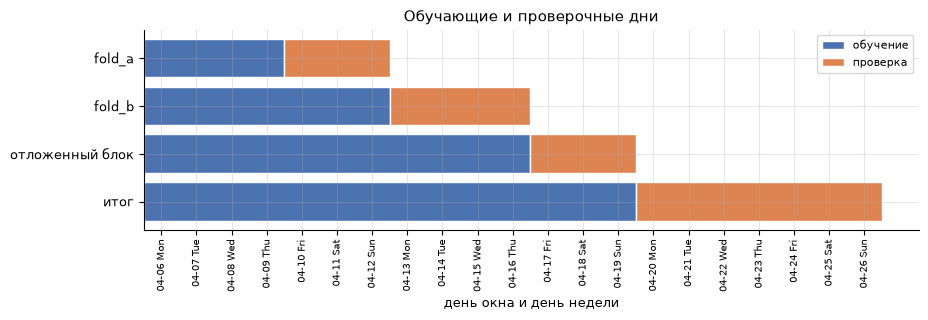

In [36]:
# Схема строится из того же определения: внутренние разбиения из scripts.FOLDS, части из meta
spans = {
    fold: {role: tuple(pd.Timestamp(day) for day in days) for role, days in roles.items()}
    for fold, roles in scripts.FOLDS.items()
}
first_day = frame.groupby('part')['window_start_ts'].min()
last_day = frame.groupby('part')['window_start_ts'].max()
spans['отложенный блок'] = {'train': (first_day['research'], last_day['research']),
                            'valid': (first_day['holdout'], last_day['holdout'])}
spans['итог'] = {'train': (first_day['research'], last_day['holdout']),
                 'valid': (first_day['test'], last_day['test'])}
all_days = pd.Series(sorted(frame['window_start_ts'].unique()))
role_colors = {'train': '#4c72b0', 'valid': '#dd8452'}
role_labels = {'train': 'обучение', 'valid': 'проверка'}
fig, ax = plt.subplots(figsize=(10, 2.6))
for position, (name, roles) in enumerate(spans.items()):
    for role, (start, end) in roles.items():
        first, last = all_days.searchsorted(start), all_days.searchsorted(end)
        ax.barh(position, last - first + 1, left=first, color=role_colors[role],
                edgecolor='white', label=role_labels.pop(role, None))
ax.set_yticks(range(len(spans)), list(spans))
ax.set_xlabel('день окна и день недели')
# Каждый день занимает отрезок [i, i + 1), подпись ставится в его середину
day_labels = [f'{day:%m-%d %a}' for day in all_days]
ax.set_xticks(np.arange(len(all_days)) + 0.5, day_labels, rotation=90, fontsize=7)
ax.invert_yaxis()
ax.set_title('Обучающие и проверочные дни')
ax.legend(fontsize=8, loc='upper right')
plt.show()

Проверка начинается на следующий день после обучения, как test после train. Зазор не нужен: метка описывает источник трафика и не созревает после окна, события после конца окна отброшены фильтром, а каждая cookie встречается только в одном окне. Группировка по cookie не нужна по той же причине. Дни связаны через одни и те же сервисы и строки User-Agent, но так же связаны train и test

Основное число это среднее официальной метрики по `fold_a` и `fold_b`, рядом всегда оба значения и их разницы с вариантом, с которым идёт сравнение. Вариант оставлял, если среднее росло и ни одно разбиение не ухудшалось. Это правило отбора, а не тест значимости: для подбора использованы одни и те же семь проверочных дней. Метрика на объединённых предсказаниях двух разбиений и метрика по дням остаются диагностикой

В `fold_a` обучение идёт на четырёх днях и 263 ботах, итоговая модель учится на 14 днях. Выходные оцениваются только в `fold_a`, дни 04-17..04-19 тоже приходятся на пятницу-воскресенье

## Метрики и срезы

Основная метрика это максимальная precision среди всех порогов, где recall не меньше 0.70, одинаковые score отмечаются целиком. Это не precision ровно при recall 0.70 и не готовый порог для новых данных. Модель выбирается по ней, остальные числа помогают понять, что изменилось

ROC-AUC описывает порядок cookie по всему списку и не зависит от доли ботов, поэтому может меняться не так, как основная метрика. AP считаю через `average_precision_score`, где в проекте написано PR-AUC, имеется в виду она. Precision, recall, F1 и доля ложно отмеченных людей считаются в диагностической точке score >= 0.5: порог условный, recall 0.70 в нём не требуется, модели по нему не выбираются. Дополнительно: recall при доле ложных срабатываний не выше 1% и доля одинаковых score

В точке, которую основная метрика выбрала на оцениваемых метках, при одинаковой precision выбран наибольший recall

In [37]:
# Срезы по платформе, клиенту, курсору, активности и возрасту
groups = scripts.slice_groups(features, meta)
validation = pd.concat([
    research.loc[parts['valid'], ['target']].join(groups).assign(split=fold)
    for fold, parts in folds.items()])
slices = pd.concat({
    column: validation.groupby([column, 'split'], observed=True)['target']
    .agg(cookies='size', bots='sum').unstack('split')
    for column in ['platform', 'ua_kind', 'web_pointer', 'activity', 'cookie_age']})
slices

cookies          bots       
split                        fold_a fold_b fold_a fold_b
platform    android            1121   1372   69.0   72.0
            ios                 140    146    8.0    5.0
            web                1364   1692  151.0  171.0
ua_kind     app                 519    605   46.0   49.0
            browser            1991   2449  149.0  167.0
            headless             67     95   21.0   24.0
            http_lib             48     61   12.0    8.0
web_pointer есть                951   1164   64.0   69.0
            нет                 413    528   87.0  102.0
activity    1-5                 559    685   27.0   24.0
            16+                1052   1252  145.0  151.0
            6-15               1014   1273   56.0   73.0
cookie_age  7 дней и больше    1992   2483  113.0  139.0
            до 7 дней           633    727  115.0  109.0

Срезы выбраны по находкам выше: платформа, вид клиента, курсор на web, активность и возраст cookie. Это диагностика, по срезам модель не выбирается. Размеры разные: в ios 8 и 5 ботов, у HTTP-библиотек 12 и 8, там видны только грубые изменения

## База и первые гипотезы

Базовая модель это алгоритм quickstart без изменений: `n_events` и `item_nunique` по событиям окна без дедупликации, пропуски нулём, `RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)`. Базу оценил на `fold_a` и `fold_b`

In [38]:
# Признаки quickstart целочисленные: сколько разных сочетаний они дают на исследовательской части
raw_counts = scripts.quickstart_features(in_window, meta).loc[research.index]
print('cookie:', len(raw_counts),
      '| разных пар (n_events, item_nunique):', len(raw_counts.drop_duplicates()))
raw_signals = scripts.signal_table(
    raw_counts.join(research[['target', 'day']]), ['n_events', 'item_nunique'])
print('AUC n_events и item_nunique по сырым событиям окна:', raw_signals['auc'].round(3).to_dict())

cookie: 9140 | разных пар (n_events, item_nunique): 971
AUC n_events и item_nunique по сырым событиям окна: {'n_events': 0.67, 'item_nunique': 0.671}


Два целочисленных признака дают 971 разную пару на 9140 cookie, поэтому у леса будет много одинаковых score, и их доля логируется с первого прогона. Одномерные AUC этих признаков 0.67 и 0.671, ниже лучших агрегатов раздела «Поведение»

Влияние удаления дублей проверил сравнением базы на исходных и очищенных событиях. Первые гипотезы меняют только признаки, модель остаётся той же

| Гипотеза | Наблюдение | Изменение |
|---|---|---|
| Объём и состав действий | `n_item_view` 0.688, доли типов событий различаются | счётчики и доли девяти типов событий |
| Выдача и разнообразие | `page_mean` 0.723, `n_locations` 0.715 | страница выдачи, локации, категории, запросы, объявления |
| Ритм | `gap_median_s` 0.271, `max_events_per_min` 0.698, длинный хвост интервалов | статистики интервалов, пик за минуту, длительность |
| Возраст cookie | до 7 дней 15-17% ботов против 5.2-5.6% | `cookie_age_h` |
| Клиент | headless 27.7%, HTTP-библиотеки 22.3%, web 10.0% | платформа и вид клиента |
| Курсор | отклонение x AUC 0.060 на web, без курсора 18.3% ботов | наличие и разброс курсора, NaN у мобильных |
| Модель | признаки с NaN и разной шкалой | градиентный бустинг вместо леса |
| Сырой User-Agent | 148 строк, все строки test есть в train | строка User-Agent как категория, только с объяснением прироста |
| Веса классов | доля ботов 0.081 | `class_weight` |

## Итоги

Для первых экспериментов выбрал объём и состав действий, разнообразие, ритм, возраст cookie, клиент и курсор

| Данные | Решение | Основание |
|---|---|---|
| События после конца окна | оставил `window_start_ts <= event_ts < window_end_ts`: начало включено, конец исключён | 40779 таких событий в train и 0 в test, проверка фильтра идёт на train |
| Капча | не использовал | все 7928 событий лежат на конце окна или позже |
| Полные дубли | удалил лишнюю копию, частичные совпадения оставил | строки совпадают по всем полям, копии у 1.47% событий людей и 1.56% ботов |
| Порядок событий | отсортировал по cookie, времени и номеру строки до расчёта интервалов | 15441 из 16000 cookie записаны в файле не по времени |
| Пропуски | неприменимые поля оставил пропуском, в первый набор вошли сами значения с пропусками; индикаторы проверены отдельно | доли пропусков близки у классов, типов и дней, AUC доли у cookie 0.53-0.56 |
| Платформа | свёл к web, android, ios, число написаний не признак | desktop встречается вместе с web, iphone вместе с ios внутри одной cookie, User-Agent согласован |
| Сырой User-Agent | в основной набор взял только вид клиента | все 148 строк test есть в train, сырую строку проверил отдельной гипотезой |
| Курсор | взял наличие и разброс координат | доступны к концу окна, определены только у web cookie с координатами |
| Возраст cookie | взял | считается от начала окна по метаданным |
| Идентификаторы | `cookie_id` не признак, `item_id` и `search_query` только в счётчиках разнообразия | ответы по идентификаторам восстанавливать нельзя |
| Статистики по другим cookie | не использовал | агрегаты считаются отдельно для каждой cookie по событиям её окна |
| Дни 04-17..04-19 | исключил из разбора, метки закрыл в `read_meta` | их дневные числа ботов уже просмотрены, полностью слепым этот блок не был |
| Схема проверки | `fold_a` учится на 04-06..04-09 и проверяется на 04-10..04-12, `fold_b` на 04-06..04-12 и 04-13..04-16, без зазора и группировки | метка описывает источник трафика и не созревает после окна, cookie не повторяются, каждый день недели проверяется один раз |
| Сводное сравнение | среднее метрики по двум разбиениям, рядом оба значения; оставлял вариант, если среднее росло и ни одно разбиение не ухудшалось | правило отбора, а не тест значимости: проверочных дней семь, повторный подбор на них завышает оценку |
| Метрики | по каждому разбиению основная, ROC-AUC, AP, recall при 1% ложных, доля одинаковых score | одна точка кривой не объясняет, что изменилось |
| Диагностическая точка | precision, recall, F1 и доля ложно отмеченных людей при score >= 0.5 | порог условный, recall 0.70 в нём не требуется |
| Срезы | платформа, вид клиента, курсор на web, активность, возраст, день | диагностика, не критерий выбора, с учётом числа ботов в срезе |
| База | алгоритм quickstart на `fold_a` и `fold_b`, на исходных и на очищенных событиях | 971 разная пара признаков на 9140 cookie |